In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

%matplotlib inline
#була помилка при Load_boston()
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
X_full = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]
y = y.reshape(-1, 1) 


feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(X_full, columns=feature_names)
df['target'] = y

print("завантажено")

завантажено


In [17]:
X = X_full[:, 5] 
X = X.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2018)

In [18]:
# DON'T_CHANGE_THIS_CODE. It is used to let you check the result is correct
print ('X_train.shape= ', X_train.shape)
print ('y_train.shape= ', y_train.shape)
X_train[:10]

X_train.shape=  (379, 1)
y_train.shape=  (379, 1)


array([[6.009],
       [5.648],
       [5.885],
       [8.297],
       [6.471],
       [4.97 ],
       [6.63 ],
       [6.678],
       [5.454],
       [8.78 ]])

In [19]:
class Linear_Regression_1():
    def __init__(self):
        pass
        
    def h(self, b, w, X):
        '''
        :param b -  float or ndarry of shape [m,1], m - number of samples
        :param w - ndarray of shape [1,n],  n - number of features
        :param X - ndarray of shape [m,n], m - number of samples, n - number of features
        '''
        assert (X.shape[1]== w.shape[1])
 
        h_res = b + np.dot(X, w.T) 

        return h_res

In [20]:
# DON'T_CHANGE_THIS_CODE. It is used to let you check the result is correct
np.random.seed(2018)
b_check= np.random.randn()
w_check= np.random.randn(1,1)
X_check= np.random.randn(10,1)
print('b= {}, \nw= {}, \nX= \n{}'.format(b_check, w_check, X_check))
lin_reg_1 = Linear_Regression_1()
lin_reg_1.h(b_check, w_check, X_check)

b= -0.276767596147759, 
w= [[0.581851]], 
X= 
[[ 2.14839926]
 [-1.279487  ]
 [ 0.50227689]
 [ 0.8560293 ]
 [-0.14279008]
 [ 0.11007867]
 [-0.68806479]
 [ 0.43356408]
 [ 0.510221  ]
 [-0.16513097]]


array([[ 0.97328067],
       [-1.02123839],
       [ 0.01548272],
       [ 0.22131391],
       [-0.35985014],
       [-0.21271821],
       [-0.67711878],
       [-0.0244979 ],
       [ 0.02010501],
       [-0.37284922]])

In [21]:
class Linear_Regression_2():
    '''linear regression using gradient descent'''
    def __init__(self):
        pass
        
    def J (self, h, y):      
        '''
        :param h - ndarray of shape (m,1)
        :param y - ndarray of shape (m,1)
        :return expression for cost function 
        '''
        if h.shape != y.shape:
            print('h.shape = {} does not match y.shape = {}.Expected {}'.format (h.shape, y.shape, (self.m,1)))
            raise Exception('Check assertion in J')    

        m = h.shape[0]
        err = h - y
        J_res = (1 / (2 * m)) * np.sum(err ** 2)

        return J_res

In [22]:
# DON'T_CHANGE_THIS_CODE. It is used to let you check the result is correct
np.random.seed(2019)
m = 10
y_check= np.random.randn(m,1)
h_check= np.random.randn(m,1)
print('y= {}, \nh= {}'.format(y_check, h_check))
lin_reg_2 = Linear_Regression_2()
lin_reg_2.m = m
lin_reg_2.J(h_check, y_check)

y= [[-0.21767896]
 [ 0.82145535]
 [ 1.48127781]
 [ 1.33186404]
 [-0.36186537]
 [ 0.68560883]
 [ 0.57376143]
 [ 0.28772767]
 [-0.23563426]
 [ 0.95349024]], 
h= [[-1.6896253 ]
 [-0.34494271]
 [ 0.0169049 ]
 [-0.51498352]
 [ 0.24450929]
 [-0.18931261]
 [ 2.67217242]
 [ 0.46480249]
 [ 0.84593044]
 [-0.50354158]]


np.float64(0.897146515186598)

In [23]:
class Linear_Regression_3():
    def __init__(self, max_iter = 1e5, alpha = 1, eps = 1e-10, verbose= 0):
        pass
        
    def h(self, b, w, X):
        '''
        :param b -  float or ndarry of shape [m,1], m - number of samples
        :param w - ndarray of shape [1,n],  n - number of features
        :param X - ndarray of shape [m,n], m - number of samples, n - number of features
        '''
        assert (X.shape[1]== w.shape[1])

        h_res = b + np.dot(X, w.T)
        
        return h_res
        
    def J_derivative(self, params, X, y): 
        '''
        :param params - tuple (b,w), where w is the 2d ndarry of shape (1,n), n- number of features 
        :param X- ndarray of shape (m, n)
        :param y - ndarray of shape (m,1)
        :return tuple of derivatrives of cost function by b and w
        '''
      
        b,w = params
        assert (w.shape == (1,self.n))                
        h_val = self.h(b,w,X)
        if  h_val.shape != (self.m, 1):
            print('h.shape = {}, but expected {}'.format (h_val.shape, (self.m, 1)))
            raise Exception('Check assertion in J_derivative')

        
        err = h_val - y
        dJ_b = (1 / self.m) * np.sum(err)
        dJ_w = (1 / self.m) * np.dot(err.T, X)
       
        
        return (dJ_b, dJ_w)

In [24]:
# DON'T_CHANGE_THIS_CODE. It is used to let you check the result is correct
np.random.seed(2020)
m = 10
n = 1
X_check= np.random.randn(m,n)
y_check= np.random.randn(m,1)
b_check= np.random.randn()
w_check= np.random.randn(1,n)
params = b_check,w_check
print('X= {}, \ny= {}, \nb= {} \nw= {}'.format(X_check, y_check, b_check, w_check))

lin_reg_3 = Linear_Regression_3()
lin_reg_3.m = m
lin_reg_3.n = n
lin_reg_3.J_derivative(params, X_check, y_check)

X= [[-1.76884571]
 [ 0.07555227]
 [-1.1306297 ]
 [-0.65143017]
 [-0.89311563]
 [-1.27410098]
 [-0.06115443]
 [ 0.06451384]
 [ 0.41011295]
 [-0.57288249]], 
y= [[-0.80133362]
 [ 1.31203519]
 [ 1.27469887]
 [-1.2143576 ]
 [ 0.31371941]
 [-1.44482142]
 [-0.3689613 ]
 [-0.76922658]
 [ 0.3926161 ]
 [ 0.05729383]], 
b= 2.0899788404287745 
w= [[0.04197131]]


(np.float64(2.1904608819958713), array([[-1.43284262]]))

In [25]:
class Linear_Regression():
    def __init__(self, max_iter = 100000, alpha = 0.01, eps = 1e-10, verbose= 0):
        self.max_iter = max_iter
        self.alpha = alpha
        self.eps = eps
        self.verbose = verbose       
        
    def h(self, b, w, X):
        assert (X.shape[1]== w.shape[1])
        h_res = b + np.dot(X, w.T)
        return h_res
        
    def J (self, h, y):      
        m = h.shape[0]
        err = h - y
        J_res = (1 / (2 * m)) * np.sum(err ** 2)
        return J_res
        
    def J_derivative(self, params, X, y): 
        b,w = params
        h_val = self.h(b,w,X)
        err = h_val - y
        dJ_b = (1 / self.m) * np.sum(err)
        dJ_w = (1 / self.m) * np.dot(err.T, X)
        return (dJ_b, dJ_w)

    def fit(self, X, y):
        self.b = 0
        self.w = np.zeros((1, X.shape[1]))
        self.m = X.shape[0]
        self.n = X.shape[1]
        self.J_hist = []
        
        for i in range(self.max_iter):
            dJ_b, dJ_w = self.J_derivative((self.b, self.w), X, y)
            self.b = self.b - self.alpha * dJ_b
            self.w = self.w - self.alpha * dJ_w
            
            cost = self.J(self.h(self.b, self.w, X), y)
            self.J_hist.append(cost)
            
            if i > 0 and abs(self.J_hist[-2] - self.J_hist[-1]) < self.eps:
                break
                
        return self
        
    def predict(self, X):
        return self.h(self.b, self.w, X)

    def score(self, X, y):
        y_pred = self.predict(X)
        u = ((y - y_pred)**2).sum()
        v = ((y - y.mean())**2).sum()
        return 1 - (u/v)
        
    def draw_cost_changes(self):
        J_hist= self.J_hist
        plt.figure()
        plt.scatter(np.arange(0, len(J_hist)), J_hist, s=20, marker='.', c='b')
        plt.xlabel('Iterations')
        plt.ylabel('Cost function J value')
        title_str = 'Complited: {}, alpha ={}, max_iter={}, eps={}'.format(len(self.J_hist)-1, self.alpha, self.max_iter,self.eps)
        plt.title(title_str)
        plt.show()

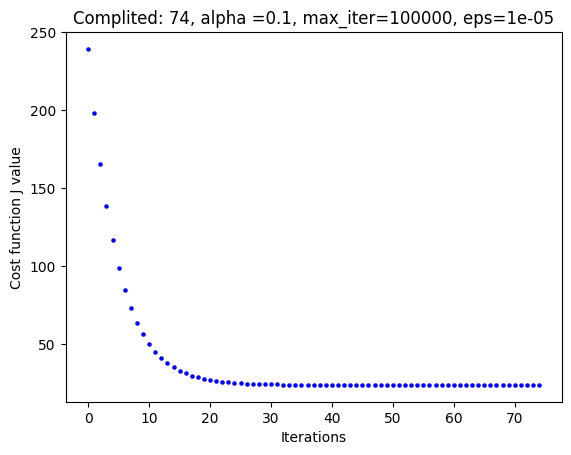

R2 training Score = 0.4554525751402274
R2 test Score = 0.5690947341445102
b: 22.19125874639131, w= [[6.29493897]]


In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = Linear_Regression(alpha= 0.1, verbose=0, eps=1e-5, max_iter=100000)
lin_reg.fit(X_train_scaled, y_train)

lin_reg.draw_cost_changes()
print('R2 training Score =', lin_reg.score(X_train_scaled, y_train))
print('R2 test Score =', lin_reg.score(X_test_scaled, y_test))
print('b: {}, w= {}'.format(lin_reg.b, lin_reg.w))

In [29]:
from sklearn.datasets import load_diabetes

X_dia, y_dia = load_diabetes(return_X_y=True)
X_train_dia, X_test_dia, y_train_dia, y_test_dia = train_test_split(X_dia, y_dia, random_state=2018)

scaler_dia = StandardScaler()
X_train_dia_scaled = scaler_dia.fit_transform(X_train_dia)
X_test_dia_scaled = scaler_dia.transform(X_test_dia)

In [30]:
ridge = Ridge()
ridge.fit(X_train_dia_scaled, y_train_dia)
print(f'Ridge R2 Score = {ridge.score(X_test_dia_scaled, y_test_dia)}')

Ridge R2 Score = 0.42512030341854057


In [31]:
lasso = Lasso()
lasso.fit(X_train_dia_scaled, y_train_dia)
print(f'Lasso R2 Score = {lasso.score(X_test_dia_scaled, y_test_dia)}')

Lasso R2 Score = 0.41305696325496966


In [34]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_dia_scaled)
X_test_poly = poly.transform(X_test_dia_scaled)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train_dia)
print(f'Polynomial R2 Score = {poly_reg.score(X_test_poly, y_test_dia)}')

Polynomial R2 Score = 0.3242491768231618
